# Normalization summary

Author: Solhee Tucker  
Module: `Codes_Solhee_Tucker/`

3 decisions documented:

1. **Score distribution** of Gilda grounding (chemprot + euadr, separated).
2. **Grounding outcome breakdown** — `failed` (score = 0) vs `rejected` (0 < score < 0.6) vs `accepted` (>= 0.6).
3. **KG comparison** via full multi-hop enumeration: baseline (no normalization) vs normalized-keep vs normalized-drop.

Threshold: `0.6`, fixed after the 200-sample POC.

## 0. Setup

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from Codes_Solhee_Tucker.poc.poc_threshold_study import thresholds, summary

sns.set_theme(style="whitegrid", context="talk")

THRESHOLD = 0.6

In [3]:
candidates = [
    Path.cwd() / "outputs",
    Path.cwd() / "Codes_Solhee_Tucker" / "outputs",
    Path.cwd().parent / "outputs",
]
OUTPUTS = next((p for p in candidates if p.exists()), None)
assert OUTPUTS is not None, (
    "Cannot find an outputs/ directory. Launch the notebook from "
    "Codes_Solhee_Tucker/ or the project root."
)

CHEMPROT_JSON = OUTPUTS / "gilda_normalized_chemprot_triples.json"
EUADR_JSON    = OUTPUTS / "gilda_normalized_euadr_triples.json"

print(f"chemprot    : {CHEMPROT_JSON.name}  exists={CHEMPROT_JSON.exists()}")
print(f"euadr       : {EUADR_JSON.name}  exists={EUADR_JSON.exists()}")

chemprot    : gilda_normalized_chemprot_triples.json  exists=True
euadr       : gilda_normalized_euadr_triples.json  exists=True


In [5]:
# Counts
with CHEMPROT_JSON.open(encoding="utf-8") as f:
    chemprot_triples = json.load(f)
with EUADR_JSON.open(encoding="utf-8") as f:
    euadr_triples = json.load(f)

print(f"chemprot triples : {len(chemprot_triples):,}")
print(f"euadr    triples : {len(euadr_triples):,}")
print(f"total    triples : {len(chemprot_triples) + len(euadr_triples):,}")

chemprot triples : 11,796
euadr    triples : 2,483
total    triples : 14,279


In [6]:
# Long-form per-entity table: one row per (triple, role).
# Head and tail are independent grounding attempts, so we analyse them as
# separate observations for sections 1 and 2.
def to_long(triples, source):
    rows = []
    for t in triples:
        for role in ("head", "tail"):
            rows.append({
                "source":   source,
                "role":     role,
                "text":     t[f"{role}_text"],
                "score":    t[f"{role}_score"],
                "db":       t[f"{role}_db"],
                "id":       t[f"{role}_id"],
                "name":     t[f"{role}_name"],
                "sentence": t["sentence"],
            })
    return rows

entities = pd.DataFrame(
    to_long(chemprot_triples, "chemprot") + to_long(euadr_triples, "euadr")
)

def _status(s):
    if s == 0:        return "failed"
    if s < THRESHOLD: return "rejected"
    return "accepted"
entities["status"] = entities["score"].apply(_status)

print(f"entity rows: {len(entities):,}")
entities.head()

entity rows: 28,558


,source,role,text,score,db,id,name,sentence,status
0,chemprot,head,Androgen,0.762317,CHEBI,CHEBI:CHEBI:50113,androgen,Androgen antagonistic effect of estramustine p...,accepted
1,chemprot,tail,estramustine,0.777778,CHEBI,CHEBI:CHEBI:4868,estramustine,Androgen antagonistic effect of estramustine p...,accepted
2,chemprot,head,Androgen,0.762317,CHEBI,CHEBI:CHEBI:50113,androgen,Androgen antagonistic effect of estramustine p...,accepted
3,chemprot,tail,estramustine phosphate,0.777778,CHEBI,CHEBI:CHEBI:68643,estramustine phosphate,Androgen antagonistic effect of estramustine p...,accepted
4,chemprot,head,Androgen,0.762317,CHEBI,CHEBI:CHEBI:50113,androgen,Androgen antagonistic effect of estramustine p...,accepted


In [7]:
# Sanity check.
display(entities.groupby("source").size().rename("n_entity_rows"))
display(entities.groupby("source")["score"].describe().round(3))
display(
    entities.groupby(["source", "status"]).size()
            .unstack(fill_value=0)
            .assign(total=lambda d: d.sum(axis=1))
)

source
chemprot    23592
euadr        4966
Name: n_entity_rows, dtype: int64

,count,mean,std,min,25%,50%,75%,max
source,,,,,,,,
chemprot,23592.0,0.457,0.379,0.0,0.0,0.556,0.778,1.0
euadr,4966.0,0.470,0.375,0.0,0.0,0.556,0.778,1.0


status,accepted,failed,rejected,total
source,,,,
chemprot,9628,8981,4983,23592
euadr,2133,1792,1041,4966


## 1. Score distribution

In [12]:
# 1.1 Non-zero subset (Pass + Rejected)
# grounding failures (score == 0) are excluded.
nz = entities[entities.score > 0].copy()

print(f"Non-zero rows : {len(nz):,} / {len(entities):,} ({len(nz)/len(entities):.1%})")
print()
print("Per-source score summary (non-zero only):")
display(nz.groupby("source")["score"].describe().round(3))

Non-zero rows : 17,785 / 28,558 (62.3%)

Per-source score summary (non-zero only):


,count,mean,std,min,25%,50%,75%,max
source,,,,,,,,
chemprot,14611.0,0.738,0.159,0.287,0.556,0.778,0.778,1.0
euadr,3174.0,0.736,0.155,0.251,0.556,0.778,0.778,1.0


Threshold: 0.6


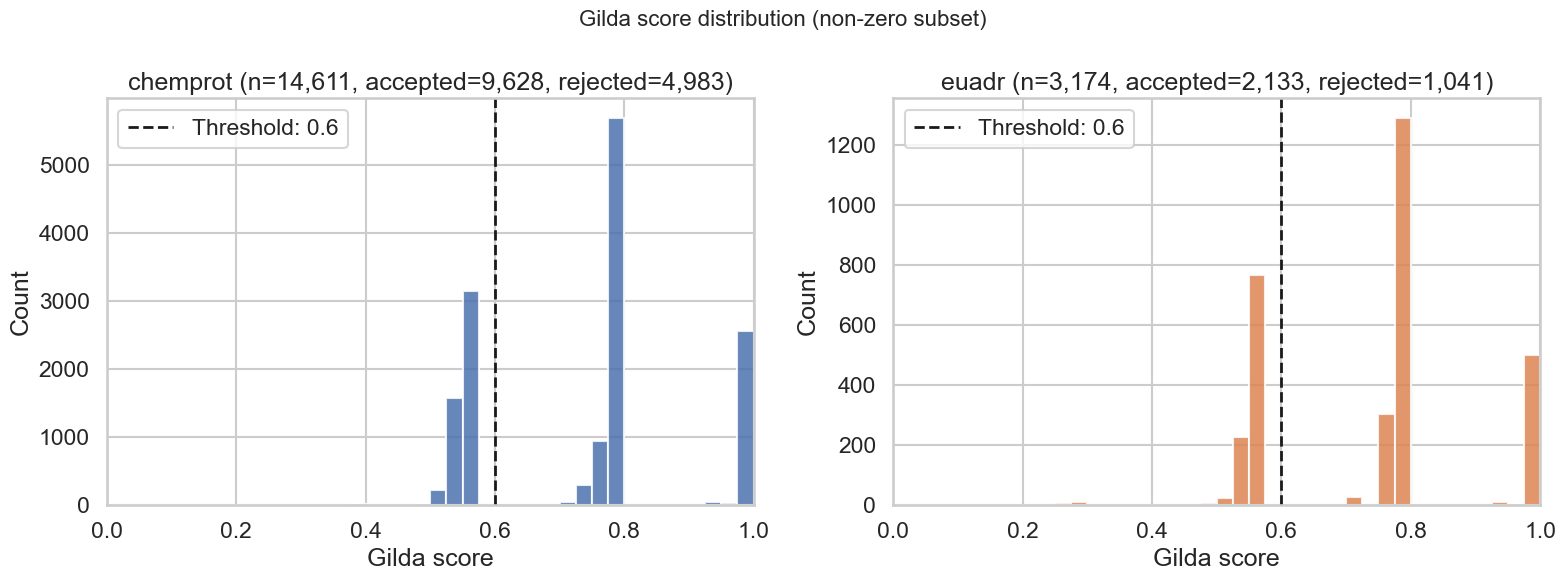

In [10]:
# 1.2 Score distribution
print("Threshold:", THRESHOLD)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
palette = {"chemprot": "C0", "euadr": "C1"}

for ax, src in zip( axes, ["chemprot", "euadr"]):
    sub = nz[nz.source == src]
    ax.hist(sub.score, bins = 40, range = (0,1), color=palette[src], alpha=0.85)
    ax.axvline(THRESHOLD, color="k", linestyle="--", linewidth=2, label = f"Threshold: {THRESHOLD}")

    n_acc = int((sub.score >= THRESHOLD).sum())
    n_rej = int((sub.score <  THRESHOLD).sum())
    ax.set_title(f"{src} (n={len(sub):,}, accepted={n_acc:,}, rejected={n_rej:,})")
    ax.set_xlabel("Gilda score")
    ax.set_ylabel("Count")
    ax.set_xlim(0,1)
    ax.legend()

plt.suptitle("Gilda score distribution (non-zero subset)", fontsize=16)
plt.tight_layout()
plt.show()

In [11]:
# 1.3 Accepted vs Rejected table
summary = (
    nz.assign(bucket=np.where(nz.score >= THRESHOLD, "accepted", "rejected"))
      .groupby(["source", "bucket"]).size()
      .unstack(fill_value=0)
)
summary["total_nonzero"] = summary["accepted"] + summary["rejected"]
summary["rejected_rate"] = (summary["rejected"] / summary["total_nonzero"]).round(3)
display(summary)


bucket,accepted,rejected,total_nonzero,rejected_rate
source,,,,
chemprot,9628,4983,14611,0.341
euadr,2133,1041,3174,0.328


In [14]:
# Section 1.4 — What gets rejected? Inspect a sample of borderline matches in [0.5, 0.6).
border = nz[(nz.score >= 0.5) & (nz.score < THRESHOLD)].copy()
print(f"Borderline rows in [0.5, {THRESHOLD}): {len(border):,}")
print()

# Balanced sample: up to 8 per source, fixed seed for reproducibility.
sample = pd.concat([
    g.sample(n=min(8, len(g)), random_state=42)
    for _, g in border.groupby("source")
]).sort_values(["source", "score"], ascending=[True, False]).reset_index(drop=True)

view = sample[["source", "score", "text", "db", "name"]].copy()
view["score"] = view["score"].round(3)
view["sentence_excerpt"] = sample["sentence"].str.slice(0, 100) + "..."
display(view)

Borderline rows in [0.5, 0.6): 5,966



,source,score,text,db,name,sentence_excerpt
0,chemprot,0.556,OATP8,HGNC,SLCO1B3,In complementary RNA (cRNA)-injected Xenopus l...
1,chemprot,0.556,BiP,HGNC,HSPA5,Salicylates inhibited ATPase activity stimulat...
2,chemprot,0.556,NKCC1,HGNC,SLC12A2,Contribution of the Na+-K+-2Cl- cotransporter ...
3,chemprot,0.556,NKCC1,HGNC,SLC12A2,Cl(-)/ HCO(3)(-) exchanger activity was increa...
4,chemprot,0.556,CoA,CHEBI,coenzyme A,Fenofibrate and GW2331 induced expression of a...
5,chemprot,0.556,SSAT,HGNC,SAT1,"During polyamine catabolism, spermine and sper..."
6,chemprot,0.549,complex I,GO,NADH dehydrogenase complex,Fibroblast cultures from the patient exhibited...
7,chemprot,0.502,A3,HGNC,TCIRG1,Substitutions for Ile(183)-Val(191) and Ser(19...
8,euadr,0.556,RANTES,HGNC,CCL5,Novel CCR5 monoclonal antibodies with potent a...
9,euadr,0.556,PDS,HGNC,SLC26A4,Allelic and non-allelic heterogeneities in pyr...


## 2. Grounding failure
Some instances have grounding failure, score == 0

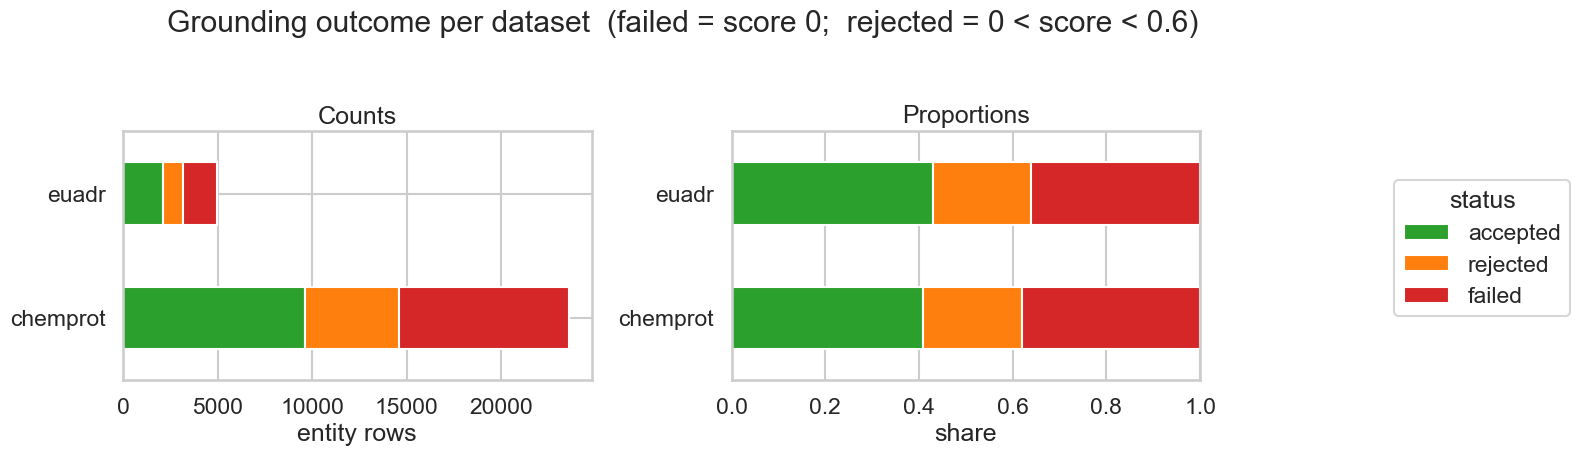

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
palette = {"accepted": "#2ca02c", "rejected": "#ff7f0e", "failed": "#d62728"}

counts.plot(kind="barh", stacked=True, ax=axes[0],
            color=[palette[c] for c in counts.columns],
            edgecolor="white", legend=False)
axes[0].set_title("Counts")
axes[0].set_xlabel("entity rows")
axes[0].set_ylabel("")

shares.plot(kind="barh", stacked=True, ax=axes[1],
            color=[palette[c] for c in shares.columns],
            edgecolor="white", legend=False)
axes[1].set_title("Proportions")
axes[1].set_xlabel("share")
axes[1].set_xlim(0, 1)
axes[1].set_ylabel("")

# Single shared legend, outside on the right.
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="status",
           loc="center left", bbox_to_anchor=(1.0, 0.5))

plt.suptitle("Grounding outcome per dataset  (failed = score 0;  rejected = 0 < score < 0.6)",
             y=1.03)
plt.tight_layout(rect=[0, 0, 0.9, 1])   # leave 10% on right for legend
plt.show()

In [17]:
# Section 2.2 — What does Gilda fail on? Sample failed surface forms.
failed = entities[entities.status == "failed"].copy()
print(f"Failed rows: {len(failed):,}")
print()

# Balanced sample, 8 per source.
fail_sample = pd.concat([
    g.sample(n=min(8, len(g)), random_state=42)
    for _, g in failed.groupby("source")
]).reset_index(drop=True)

# Add token count to spot the "long multi-word phrase" pattern.
fail_sample["n_tokens"] = fail_sample["text"].str.split().str.len()

view = fail_sample[["source", "text", "n_tokens"]].copy()
view["sentence_excerpt"] = fail_sample["sentence"].str.slice(0, 100) + "..."
display(view)

Failed rows: 10,773



,source,text,n_tokens,sentence_excerpt
0,chemprot,MPP+-induced,1,The MPP+-induced release of [3H]-MPP+ was full...
1,chemprot,Ile(183)-Val(191,1,Substitutions for Ile(183)-Val(191) and Ser(19...
2,chemprot,PBZ,1,These differences from the horse might be the ...
3,chemprot,pyridoxal phosphate-dependent transaminases,3,"In the study reported here, the effects of acu..."
4,chemprot,5-hydroxytryptamine-3,1,The anti-emetic and pharmacological profile of...
5,chemprot,arachidonic,1,"By contrast, membrane expression of annexin-1,..."
6,chemprot,alpha(2)-AR,1,"However, in contrast to the selective alpha(2)..."
7,chemprot,ammonium transporter,2,Immunoreactivity for a second putative ammoniu...
8,euadr,BALF mediators,2,Regulation of hepatocyte growth factor secreti...
9,euadr,visceral varicella-zoster infection,3,Quantification of circulating varicella-zoster...


## 3. KG Comparison

In [18]:
# Section 3 — KG comparison via downstream multi-hop reasoning output.
# All path files were produced by the ORIGINAL authors' code, applied
# identically to baseline / norm-keep / norm-drop KGs:
#   - multi_hop_reasoning_v2.py     → "all"        (max_hops=4)
#   - filtered_multi_hop.reasoning_v2.py → "filtered"  (max_hops=3, CPR-anchored)

REPO_ROOT    = OUTPUTS.parent.parent
BASELINE_DIR = REPO_ROOT / "chemprot-relexner-pipeline-main" / "chemprot-relexner-pipeline-main"

PATH_FILES = {
    ("baseline",  "all"):      BASELINE_DIR / "inferred_multi_hop_links_max_hop_4.json",
    ("baseline",  "filtered"): BASELINE_DIR / "filtered_inferred_links.json",
    ("norm_keep", "all"):      OUTPUTS / "inferred_multi_hop_links_normalized.json",
    ("norm_keep", "filtered"): OUTPUTS / "filtered_inferred_links_normalized.json",
    ("norm_drop", "all"):      OUTPUTS / "inferred_multi_hop_links_normalized_drop.json",
    ("norm_drop", "filtered"): OUTPUTS / "filtered_inferred_links_normalized_drop.json",
}

for k, p in PATH_FILES.items():
    print(f"{str(k):<28} exists={p.exists()}  {p.name}")

('baseline', 'all')          exists=True  inferred_multi_hop_links_max_hop_4.json
('baseline', 'filtered')     exists=True  filtered_inferred_links.json
('norm_keep', 'all')         exists=True  inferred_multi_hop_links_normalized.json
('norm_keep', 'filtered')    exists=True  filtered_inferred_links_normalized.json
('norm_drop', 'all')         exists=True  inferred_multi_hop_links_normalized_drop.json
('norm_drop', 'filtered')    exists=True  filtered_inferred_links_normalized_drop.json


In [20]:
# Load each file and count entries (deterministic — these are saved outputs).
results = {}
for (kg, metric), path in PATH_FILES.items():
    with path.open() as f:
        data = json.load(f)
    results[(kg, metric)] = len(data)
    print(f"{kg:>10} / {metric:>8} : {len(data):>10,} paths")

print("Baseline: String norm")
# Pivot into a 3 × 2 table (baseline / norm_keep / norm_drop  ×  all / filtered).
counts_df = (
    pd.Series(results)
      .rename_axis(["kg", "metric"]).rename("path_count")
      .unstack("metric")
      .loc[["baseline", "norm_keep", "norm_drop"], ["all", "filtered"]]
)

# Add Δ and % vs baseline.
delta = counts_df.subtract(counts_df.loc["baseline"], axis=1).astype(int)
pct   = (delta.div(counts_df.loc["baseline"], axis=1) * 100).round(1)

table = pd.DataFrame({
    "all":             counts_df["all"],
    "all_Δ":           delta["all"],
    "all_%":           pct["all"],
    "filtered":        counts_df["filtered"],
    "filtered_Δ":      delta["filtered"],
    "filtered_%":      pct["filtered"],
})
display(table)

  baseline /      all :    844,143 paths
  baseline / filtered :     34,760 paths
 norm_keep /      all :    890,358 paths
 norm_keep / filtered :     37,060 paths
 norm_drop /      all :     48,006 paths
 norm_drop / filtered :      3,359 paths
Baseline: String norm


,all,all_Δ,all_%,filtered,filtered_Δ,filtered_%
kg,,,,,,
baseline,844143,0,0.0,34760,0,0.0
norm_keep,890358,46215,5.5,37060,2300,6.6
norm_drop,48006,-796137,-94.3,3359,-31401,-90.3


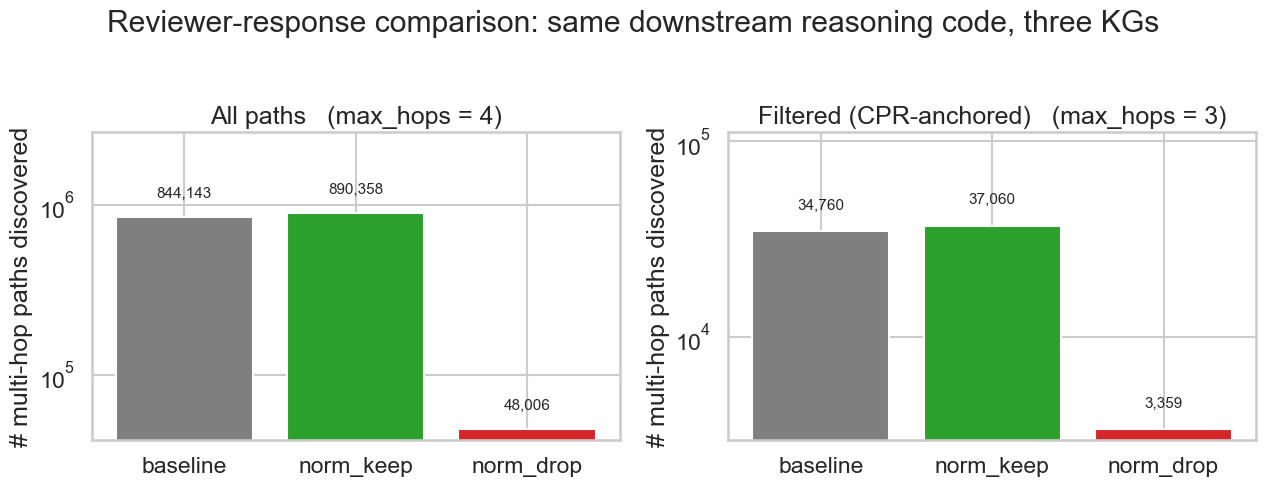

In [22]:
# Bar chart — log scale because the drop KG is two orders of magnitude smaller.
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
order  = ["baseline", "norm_keep", "norm_drop"]
colors = ["#7f7f7f", "#2ca02c", "#d62728"]

titles = {
    "all":      "All paths   (max_hops = 4)",
    "filtered": "Filtered (CPR-anchored)   (max_hops = 3)",
}

for ax, metric in zip(axes, ["all", "filtered"]):
    vals = [counts_df.loc[k, metric] for k in order]
    bars = ax.bar(order, vals, color=colors, edgecolor="white")
    ax.set_title(titles[metric])
    ax.set_ylabel("# multi-hop paths discovered")
    ax.set_yscale("log")

    # Headroom: extend y upper bound so labels never collide with the frame.
    ax.set_ylim(top=max(vals) * 3)

    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, v * 1.25,
                f"{v:,}", ha="center", va="bottom", fontsize=11)

plt.suptitle("Reviewer-response comparison: same downstream reasoning code, three KGs", y=1.03)
plt.tight_layout()
plt.show()

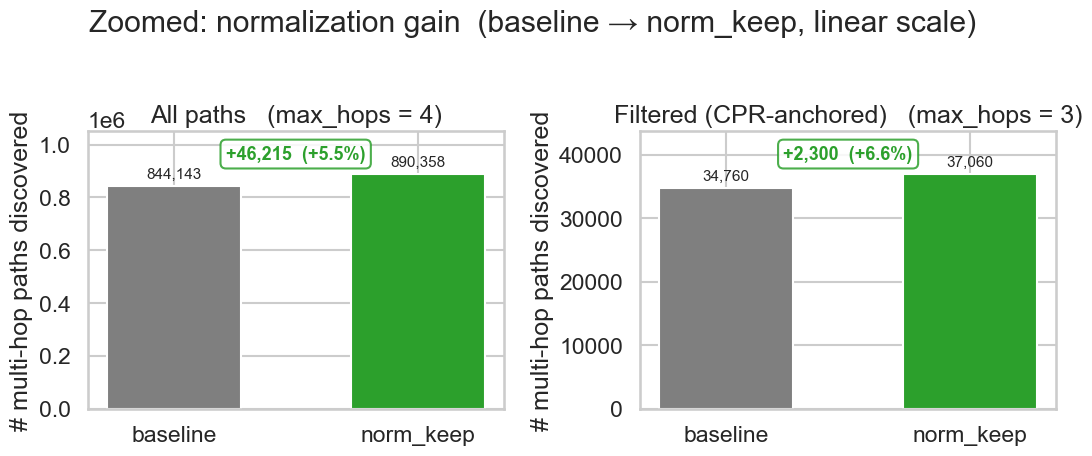

In [23]:
# Section 3.4 — Zoomed view: baseline vs norm_keep only (the recommended policy).
# The previous plot is dominated by the drop KG; this plot isolates the
# normalization gain in keep_as_raw on a linear scale.
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
order  = ["baseline", "norm_keep"]
colors = ["#7f7f7f", "#2ca02c"]

titles = {
    "all":      "All paths   (max_hops = 4)",
    "filtered": "Filtered (CPR-anchored)   (max_hops = 3)",
}

for ax, metric in zip(axes, ["all", "filtered"]):
    vals = [counts_df.loc[k, metric] for k in order]
    bars = ax.bar(order, vals, color=colors, edgecolor="white", width=0.55)
    ax.set_title(titles[metric])
    ax.set_ylabel("# multi-hop paths discovered")

    # Linear scale — values are within ~6% of each other.
    ax.set_ylim(top=max(vals) * 1.18)

    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, v * 1.02,
                f"{v:,}", ha="center", va="bottom", fontsize=11)

    # Annotate the gain prominently.
    gain     = vals[1] - vals[0]
    gain_pct = gain / vals[0] * 100
    ax.text(0.5, 0.90, f"+{gain:,}  ({gain_pct:+.1f}%)",
            transform=ax.transAxes, ha="center", fontsize=13,
            fontweight="bold", color="#2ca02c",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                      edgecolor="#2ca02c", alpha=0.85))

plt.suptitle("Zoomed: normalization gain  (baseline → norm_keep, linear scale)", y=1.03)
plt.tight_layout()
plt.show()

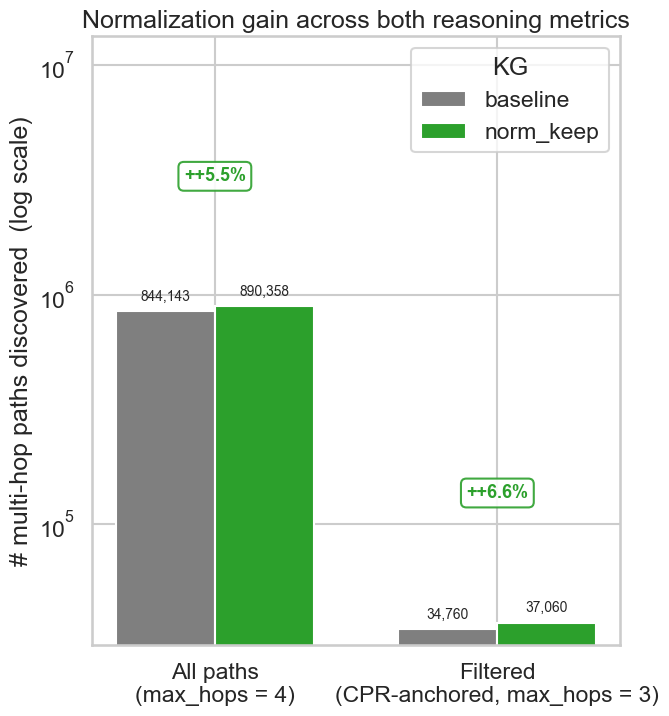

In [24]:
# Section 3.5 — All four bars on a single log y-axis.
# Lets the reader compare both (baseline ↔ norm_keep) AND (all ↔ filtered)
# in one glance.
fig, ax = plt.subplots(figsize=(7, 7.5))

metrics = ["all", "filtered"]
kgs     = ["baseline", "norm_keep"]
colors  = {"baseline": "#7f7f7f", "norm_keep": "#2ca02c"}

x = np.arange(len(metrics))
width = 0.35

for i, kg in enumerate(kgs):
    vals = [counts_df.loc[kg, m] for m in metrics]
    offset = (i - 0.5) * width
    bars = ax.bar(x + offset, vals, width, color=colors[kg],
                  edgecolor="white", label=kg)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, v * 1.08,
                f"{v:,}", ha="center", va="bottom", fontsize=10)

# Gain % box above each metric pair.
for i, m in enumerate(metrics):
    base = counts_df.loc["baseline", m]
    keep = counts_df.loc["norm_keep", m]
    gain_pct = (keep - base) / base * 100
    ymax = max(base, keep)
    ax.text(x[i], ymax * 3.5, f"+{gain_pct:+.1f}%",
            ha="center", fontsize=13, fontweight="bold", color="#2ca02c",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                      edgecolor="#2ca02c", alpha=0.9))

ax.set_xticks(x)
ax.set_xticklabels(["All paths\n(max_hops = 4)",
                    "Filtered\n(CPR-anchored, max_hops = 3)"])
ax.set_ylabel("# multi-hop paths discovered  (log scale)")
ax.set_yscale("log")
ax.set_ylim(top=counts_df.values.max() * 15)   # headroom for gain box
ax.legend(title="KG", loc="upper right")
ax.set_title("Normalization gain across both reasoning metrics")

plt.tight_layout()
plt.show()